In [86]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pickle

In [87]:
# Load the Dataset
data = pd.read_csv("Churn_Modelling.csv")

In [88]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [89]:
## Preprocess the data
# Drop irrelevant columns
data = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [90]:
data

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [91]:
# Encode categorical varaibles
label_encoder_gender = LabelEncoder()
data['Gender'] = label_encoder_gender.fit_transform(data['Gender'])

In [92]:
data['Gender']

0       0
1       0
2       0
3       0
4       0
       ..
9995    1
9996    1
9997    0
9998    1
9999    0
Name: Gender, Length: 10000, dtype: int32

In [93]:
data

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,0,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1
3,699,France,0,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,1,39,5,0.00,2,1,0,96270.64,0
9996,516,France,1,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,0,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,1,42,3,75075.31,2,1,0,92888.52,1


In [94]:
data["Geography"]

0        France
1         Spain
2        France
3        France
4         Spain
         ...   
9995     France
9996     France
9997     France
9998    Germany
9999     France
Name: Geography, Length: 10000, dtype: object

In [96]:
data[["Geography"]]

,Geography
0,France
1,Spain
2,France
3,France
4,Spain
...,...
9995,France
9996,France
9997,France
9998,Germany


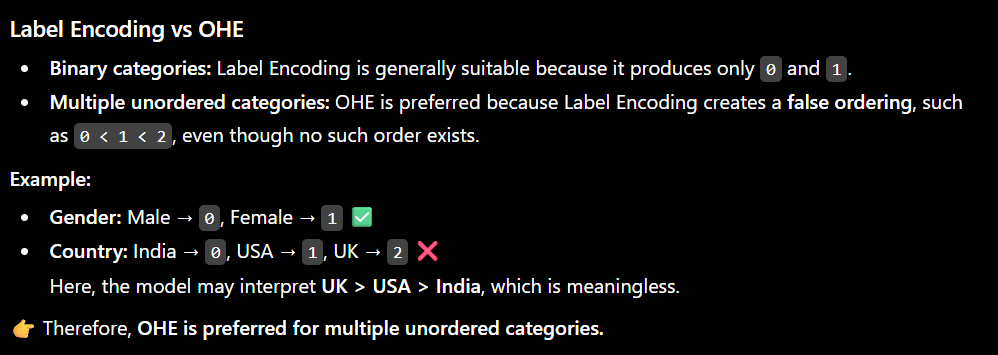

In [97]:
data[['Geography']]

,Geography
0,France
1,Spain
2,France
3,France
4,Spain
...,...
9995,France
9996,France
9997,France
9998,Germany


In [98]:
# One Hot encoding : "Geography"
from sklearn.preprocessing import OneHotEncoder
onehot_encoder_geo = OneHotEncoder()
geo_encoder = onehot_encoder_geo.fit_transform(data[['Geography']])
geo_encoder

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 10000 stored elements and shape (10000, 3)>

In [99]:
geo_encoder.toarray()

array([[1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       ...,
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.]])

In [100]:
geo_encoder.toarray().shape

(10000, 3)

In [101]:
import numpy as np
print(np.array(onehot_encoder_geo.get_feature_names_out()))

['Geography_France' 'Geography_Germany' 'Geography_Spain']


In [102]:
geo_column  = np.array(onehot_encoder_geo.get_feature_names_out())

In [103]:
geo_encoded_df = pd.DataFrame(geo_encoder.toarray(), columns=geo_column)

In [104]:
geo_encoded_df

,Geography_France,Geography_Germany,Geography_Spain
0,1.0,0.0,0.0
1,0.0,0.0,1.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,0.0,0.0,1.0
...,...,...,...
9995,1.0,0.0,0.0
9996,1.0,0.0,0.0
9997,1.0,0.0,0.0
9998,0.0,1.0,0.0


In [105]:
# Combine OHE with original data
data = pd.concat([data.drop('Geography',axis=1), geo_encoded_df],axis=1)

In [106]:
data.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0


In [107]:
# Save the encoders and scaler
import pickle
with open("label_encoder_gender.pkl","wb") as file:
    pickle.dump(label_encoder_gender,file)

In [108]:
with open("onehot_encoder_geo.pkl","wb") as file:
    pickle.dump(onehot_encoder_geo,file)

In [109]:
data.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0


In [110]:
# Divide the datatset into independent and dependent features
X = data.drop(["Exited"],axis=1)
y = data['Exited']

In [111]:
X.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1.0,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0.0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1.0,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,1.0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0.0,0.0,1.0


In [112]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

In [113]:
# Split the data in training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [114]:
X_train

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
9254,686,1,32,6,0.00,2,1,1,179093.26,1.0,0.0,0.0
1561,632,1,42,4,119624.60,2,1,1,195978.86,0.0,1.0,0.0
1670,559,1,24,3,114739.92,1,1,0,85891.02,0.0,0.0,1.0
6087,561,0,27,9,135637.00,1,1,0,153080.40,1.0,0.0,0.0
6669,517,1,56,9,142147.32,1,0,0,39488.04,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
5734,768,1,54,8,69712.74,1,1,1,69381.05,1.0,0.0,0.0
5191,682,0,58,1,0.00,1,1,1,706.50,1.0,0.0,0.0
5390,735,0,38,1,0.00,3,0,0,92220.12,1.0,0.0,0.0
860,667,1,43,8,190227.46,1,1,0,97508.04,1.0,0.0,0.0


In [115]:
# Scale these features
scaler = StandardScaler()
x_train = scaler.fit_transform(X_train)
x_test = scaler.transform(X_test)

In [116]:
x_train

array([[ 0.35649971,  0.91324755, -0.6557859 , ...,  1.00150113,
        -0.57946723, -0.57638802],
       [-0.20389777,  0.91324755,  0.29493847, ..., -0.99850112,
         1.72572313, -0.57638802],
       [-0.96147213,  0.91324755, -1.41636539, ..., -0.99850112,
        -0.57946723,  1.73494238],
       ...,
       [ 0.86500853, -1.09499335, -0.08535128, ...,  1.00150113,
        -0.57946723, -0.57638802],
       [ 0.15932282,  0.91324755,  0.3900109 , ...,  1.00150113,
        -0.57946723, -0.57638802],
       [ 0.47065475,  0.91324755,  1.15059039, ..., -0.99850112,
         1.72572313, -0.57638802]])

In [117]:
x_test

array([[-0.57749609,  0.91324755, -0.6557859 , ..., -0.99850112,
         1.72572313, -0.57638802],
       [-0.29729735,  0.91324755,  0.3900109 , ...,  1.00150113,
        -0.57946723, -0.57638802],
       [-0.52560743, -1.09499335,  0.48508334, ..., -0.99850112,
        -0.57946723,  1.73494238],
       ...,
       [ 0.81311987, -1.09499335,  0.77030065, ...,  1.00150113,
        -0.57946723, -0.57638802],
       [ 0.41876609,  0.91324755, -0.94100321, ...,  1.00150113,
        -0.57946723, -0.57638802],
       [-0.24540869,  0.91324755,  0.00972116, ..., -0.99850112,
         1.72572313, -0.57638802]])

In [118]:
with open('scaler.pkl','wb') as file:
    pickle.dump(scaler,file)

In [119]:
data

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,1,39,5,0.00,2,1,0,96270.64,0,1.0,0.0,0.0
9996,516,1,35,10,57369.61,1,1,1,101699.77,0,1.0,0.0,0.0
9997,709,0,36,7,0.00,1,0,1,42085.58,1,1.0,0.0,0.0
9998,772,1,42,3,75075.31,2,1,0,92888.52,1,0.0,1.0,0.0


# ANN Implementation

In [120]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
import datetime

In [121]:
(x_train.shape[1],)

(12,)

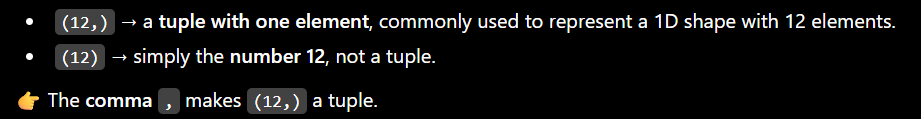

In [122]:
#  Building our ANN model
model = Sequential(
    [
        Dense(64, activation='relu', input_shape = (x_train.shape[1],)), ## HL1 -> Connected with I/P Layer. Also, input shape format should be of tuple format so written the data in tuple form: (x_train.shape[1],))
        Dense(32, activation='relu'),  # H.L.2 -->no need to give I/P shape here as ANN is fully connected neural network so Sequential instance will automatically calculate the input shape for H.L2.
        Dense(1,activation='sigmoid') # output layer with 1 neuron as Problem Statement is a binary classification .P.S.
    ]
)

In [123]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_7 (Dense)             (None, 64)                832       
                                                                 
 dense_8 (Dense)             (None, 32)                2080      
                                                                 
 dense_9 (Dense)             (None, 1)                 33        
                                                                 
Total params: 2945 (11.50 KB)
Trainable params: 2945 (11.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [124]:
opt = tf.keras.optimizers.Adam(learning_rate=0.01)
loss = tf.keras.losses.BinaryCrossentropy()
loss,opt

(<keras.src.losses.BinaryCrossentropy at 0x24df81a7af0>,
 <keras.src.optimizers.adam.Adam at 0x24df81a7a30>)

In [125]:
# Compile the model to do forward & backward propogation on the ANN:
model.compile(optimizer=opt, loss="binary_crossentropy", metrics=['accuracy'])

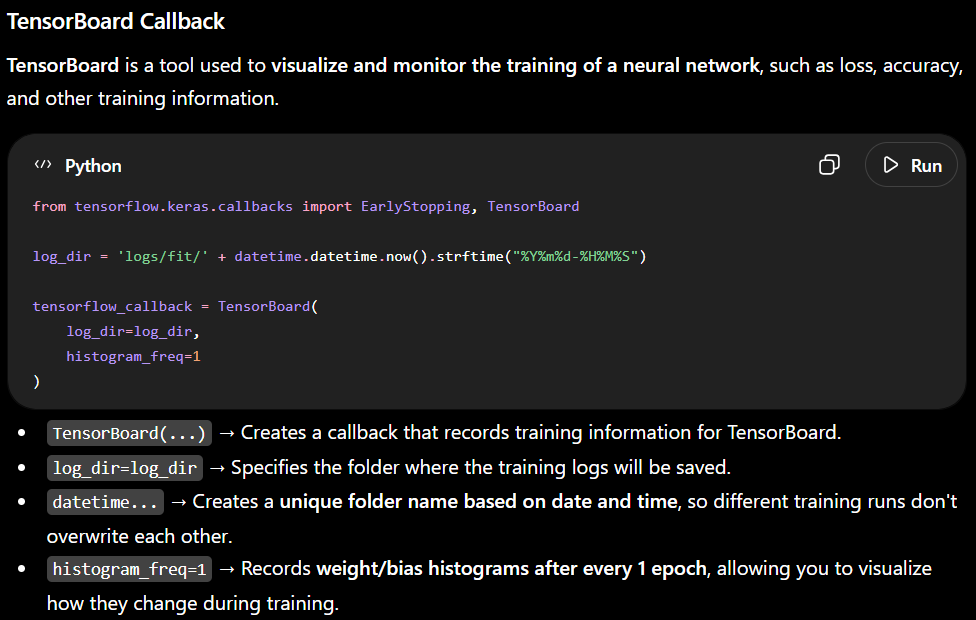

In [126]:
# Set up the  Tensorboard to visualize training phase of ANN
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard

log_dir = 'logs/fit/' + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorflow_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

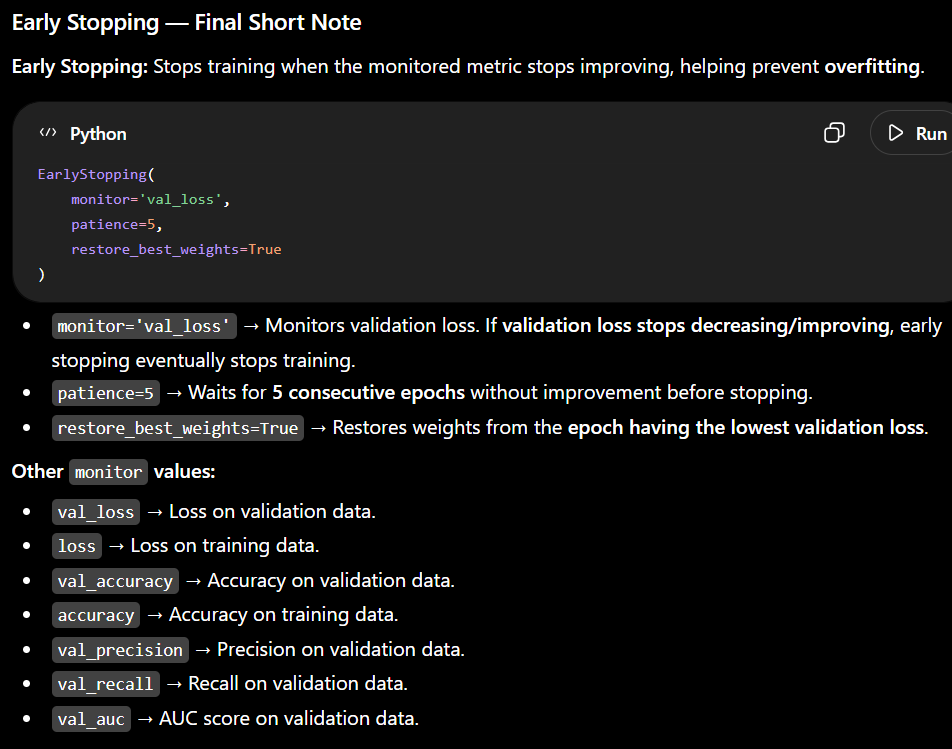
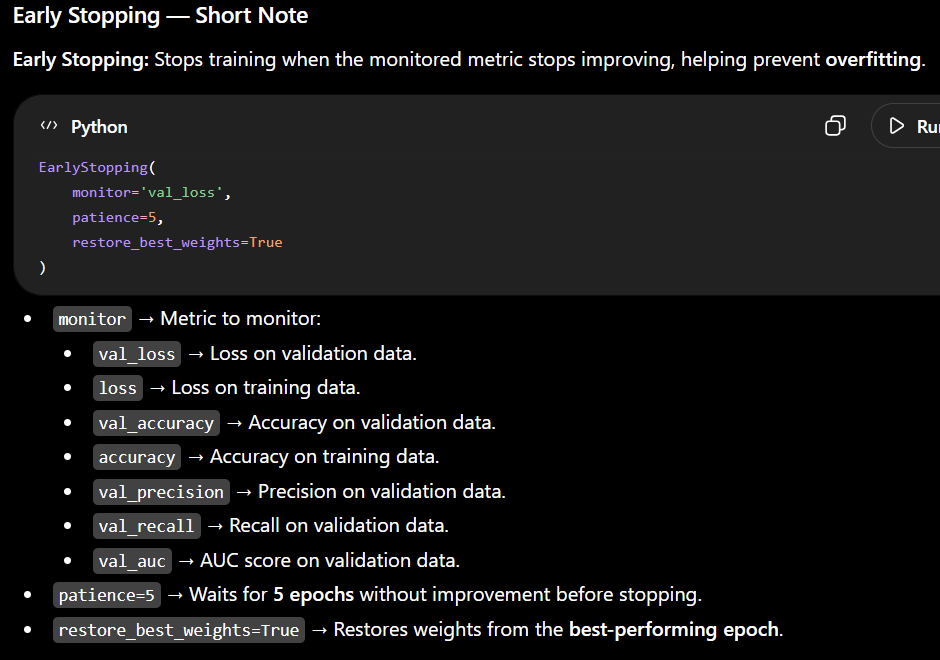

In [127]:
# Set up Early Stopping
early_stopping_callback =  EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [128]:
### Train the Model
history = model.fit(
    X_train, y_train, validation_data = (X_test,y_test),epochs=100, callbacks=[tensorflow_callback,early_stopping_callback])

Epoch 1/100
250/250 [==============================] - 2s 4ms/step - loss: 412.3001 - accuracy: 0.6665 - val_loss: 294.4333 - val_accuracy: 0.8035
Epoch 2/100
250/250 [==============================] - 1s 3ms/step - loss: 67.7668 - accuracy: 0.6801 - val_loss: 47.6684 - val_accuracy: 0.6635
Epoch 3/100
250/250 [==============================] - 1s 3ms/step - loss: 35.1831 - accuracy: 0.6751 - val_loss: 32.4697 - val_accuracy: 0.4510
Epoch 4/100
250/250 [==============================] - 1s 3ms/step - loss: 19.6207 - accuracy: 0.6779 - val_loss: 17.7914 - val_accuracy: 0.8035
Epoch 5/100
250/250 [==============================] - 1s 3ms/step - loss: 8.2794 - accuracy: 0.6759 - val_loss: 2.4602 - val_accuracy: 0.7600
Epoch 6/100
250/250 [==============================] - 1s 3ms/step - loss: 5.4506 - accuracy: 0.6779 - val_loss: 6.9131 - val_accuracy: 0.8035
Epoch 7/100
250/250 [==============================] - 1s 3ms/step - loss: 2.6479 - accuracy: 0.6996 - val_loss: 2.3916 - val_accura

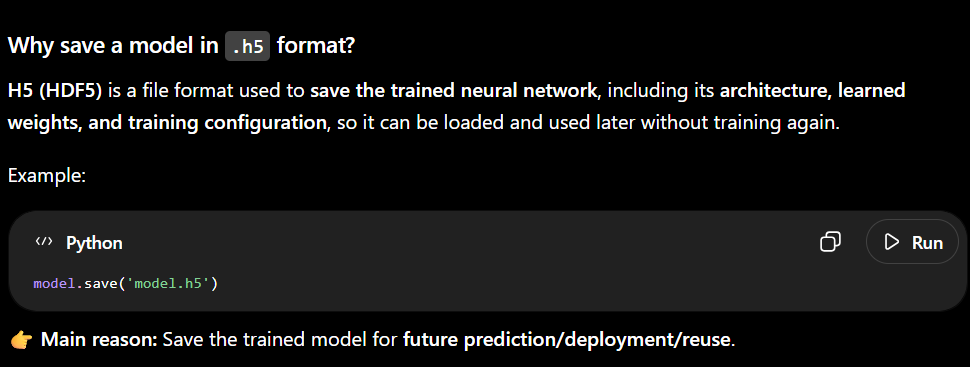

In [129]:
model.save("model.h5")

c:\Users\Omkar Raut\Desktop\DataSceince\DL-venv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


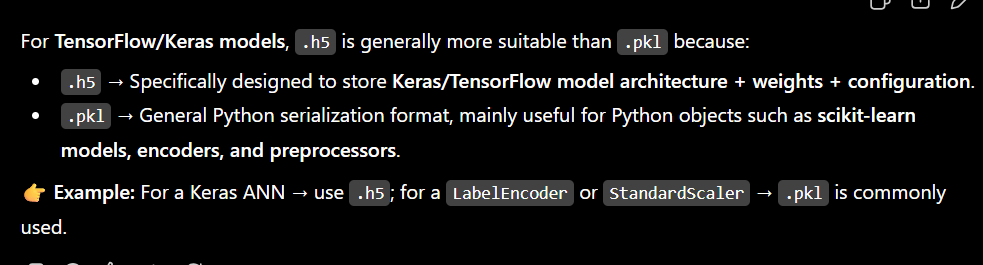

In [130]:
# Load the Tensorboard Extension
import pkg_resources
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


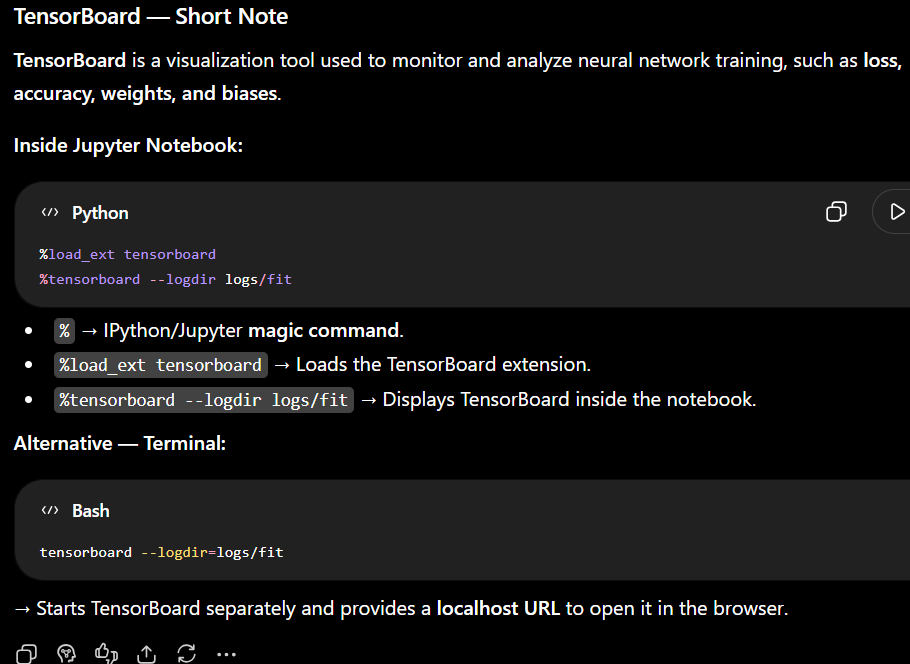

In [131]:
%tensorboard --logdir logs/fit/

Reusing TensorBoard on port 6008 (pid 14612), started 1:43:39 ago. (Use '!kill 14612' to kill it.)